# LCEL (LangChain Expression Language)
- LCEL은 LangChain에서 **체인(Chain)** 을 선언적으로 구성하기 위한 언어입니다.

### 주요 특징
- 선언적 구성: 작업의 순서와 흐름을 명시적으로 정의하여, 복잡한 로직을 간결하게 표현할 수 있습니다.
- 파이프 연산자(|) 지원: Unix의 파이프처럼, 함수의 출력을 다음 함수의 입력으로 전달하여 체인을 구성합니다.

> 코드 예제 
```ini
chain = prompt | llm | parser
```

# 스트리밍 (Streaming)
- 긴 응답을 실시간으로 받을 수 있습니다.

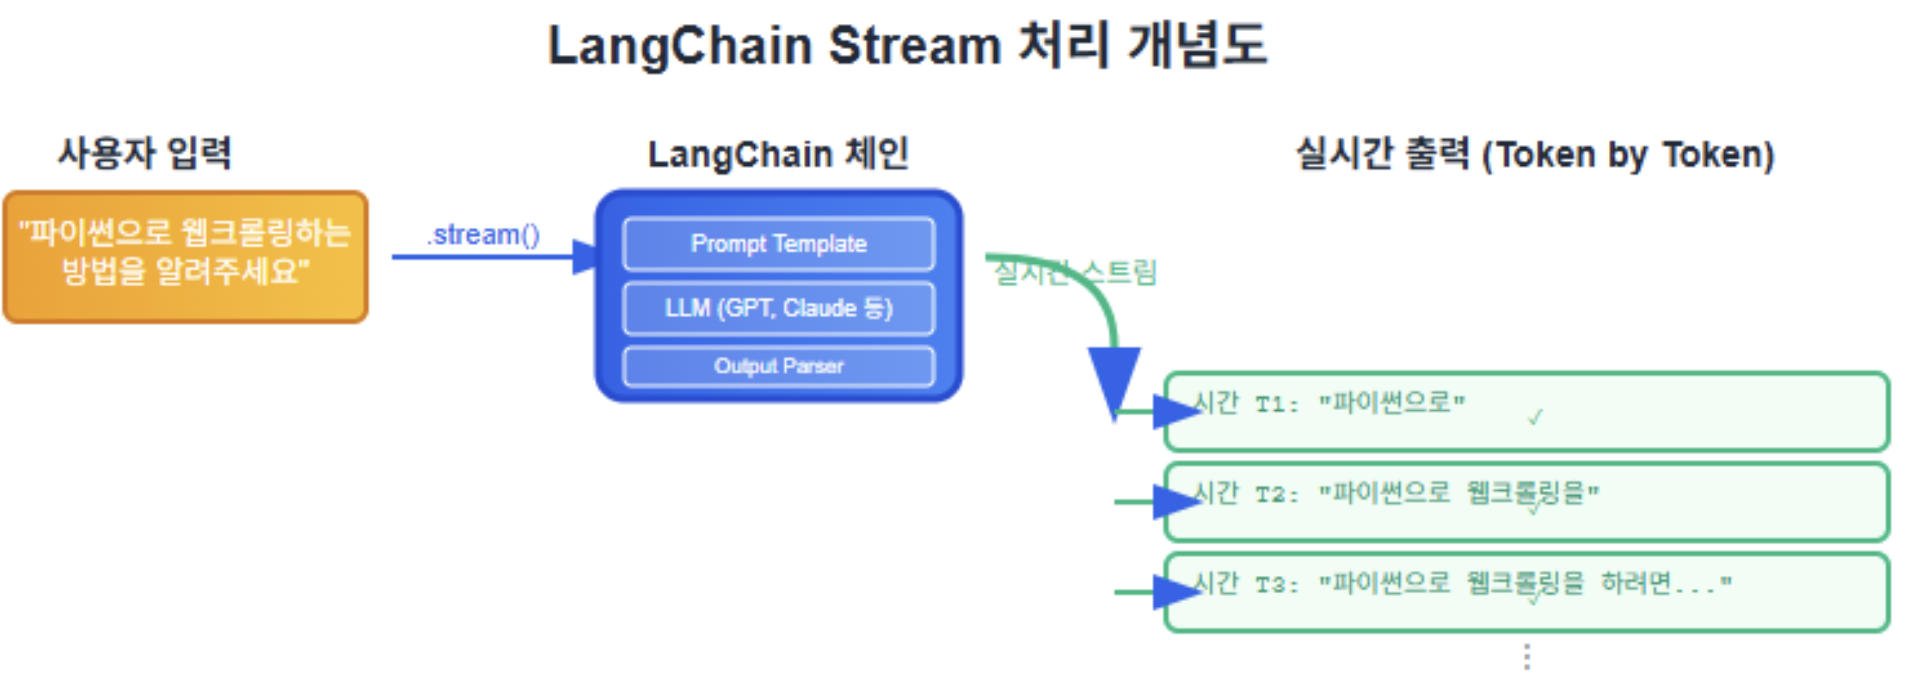

# Model

In [1]:
from langchain_ollama.chat_models import ChatOllama 

llm = ChatOllama(
    model="gemma3:4b",
    temperature=0.1,
    top_p=1.0,
    num_predict=256,
    keep_alive="5m"
)

# Parser

In [2]:
from langchain_core.output_parsers import StrOutputParser

# OutputParser 설정
output_parser = StrOutputParser()

# PromptTemplate

In [3]:
from langchain_core.prompts import PromptTemplate

# 긴 응답을 위한 프롬프트
story_prompt = PromptTemplate.from_template(
    template="{topic}에 대한 흥미로운 이야기를 간단하게 써주세요."
)

# Chain

In [4]:
story_chain = story_prompt | llm

## 스트리밍 실행

In [5]:
import time

# 스트리밍 실행
print("=== 스트리밍 응답 ===")
print("주제: 우주 여행")
print("-" * 30)

for chunk in story_chain.stream({"topic": "우주 여행"}):
    print(chunk.content, end="", flush=True)
    time.sleep(0.02)  # 스트리밍 효과를 위한 지연

print("\n" + "=" * 30)

=== 스트리밍 응답 ===
주제: 우주 여행
------------------------------
물론입니다. 다음은 우주 여행에 대한 짧은 이야기입니다.

지구에서 멀리 떨어진 곳에 있는 작은 행성인 아스트라에서 엘라는 우주 여행을 꿈꾸는 젊은 천문학자였습니다. 그녀는 밤하늘을 보면서 별들이 반짝이는 것을 보았고, 그들이 우리를 둘러싼 광대한 우주에 대한 수많은 질문을 던지는 것을 보았습니다. 그녀는 우주를 탐험하고 그 비밀을 밝혀내는 것을 꿈꿨습니다.

어느 날, 엘라는 우주 탐사선인 '스타드래곤'에 합류하게 되었습니다. 그녀는 우주 탐사선에 합류한 과학자, 엔지니어, 조종사들과 함께 우주를 탐험하는 데 참여하게 되었습니다. 그들은 새로운 행성을 찾고, 외계 생명체를 찾고, 우주의 비밀을 밝히기 위해 함께 여행했습니다.

스타드래곤은 광대한 우주를 여행하면서 수많은 위험과 모험을 겪었습니다. 그들은 거대한 운석장, 폭풍우, 그리고 다른 우주 탐사선과 충돌했습니다. 하지만 엘라와 그녀의
